In [1]:
import webdataset as wds
import torchvision.transforms as T
import torch

In [8]:
!ls /weka/oe-data-default/georges/datasets/cc3m-wds/

README.md	     cc3m-train-0196.tar  cc3m-train-0394.tar
_info.json	     cc3m-train-0197.tar  cc3m-train-0395.tar
cc3m-train-0000.tar  cc3m-train-0198.tar  cc3m-train-0396.tar
cc3m-train-0001.tar  cc3m-train-0199.tar  cc3m-train-0397.tar
cc3m-train-0002.tar  cc3m-train-0200.tar  cc3m-train-0398.tar
cc3m-train-0003.tar  cc3m-train-0201.tar  cc3m-train-0399.tar
cc3m-train-0004.tar  cc3m-train-0202.tar  cc3m-train-0400.tar
cc3m-train-0005.tar  cc3m-train-0203.tar  cc3m-train-0401.tar
cc3m-train-0006.tar  cc3m-train-0204.tar  cc3m-train-0402.tar
cc3m-train-0007.tar  cc3m-train-0205.tar  cc3m-train-0403.tar
cc3m-train-0008.tar  cc3m-train-0206.tar  cc3m-train-0404.tar
cc3m-train-0009.tar  cc3m-train-0207.tar  cc3m-train-0405.tar
cc3m-train-0010.tar  cc3m-train-0208.tar  cc3m-train-0406.tar
cc3m-train-0011.tar  cc3m-train-0209.tar  cc3m-train-0407.tar
cc3m-train-0012.tar  cc3m-train-0210.tar  cc3m-train-0408.tar
cc3m-train-0013.tar  cc3m-train-0211.tar  cc3m-train-0409.tar
cc3m-train-0014.tar

In [ ]:
dataset = wds.WebDataset(
    "/weka/oe-data-default/georges/datasets/cc3m-wds/cc3m-train-{0000..0575}.tar"
).decode("pil")#.rename(image="image", caption="caption")

/opt/miniconda3/envs/uvit/lib/python3.10/site-packages/webdataset/compat.py:389: UserWarning: WebDataset(shardshuffle=...) is None; set explicitly to False or a number
  warnings.warn(


In [59]:
resolution = 512
image_transforms = T.Compose(
    [
        # T.CenterCrop(resolution),
        # T.Resize((resolution, resolution)),
        T.ToTensor(),
    ]
)

In [60]:
dataset = dataset.rename(image="jpg", caption="txt")\
.map_dict(image=image_transforms, caption=lambda x: x.strip())

In [61]:
it = iter(dataset)
x = next(it)
x = next(it)
x = next(it)

In [62]:
x.keys()

dict_keys(['__key__', '__url__', '__local_path__', 'json', 'image', 'caption'])

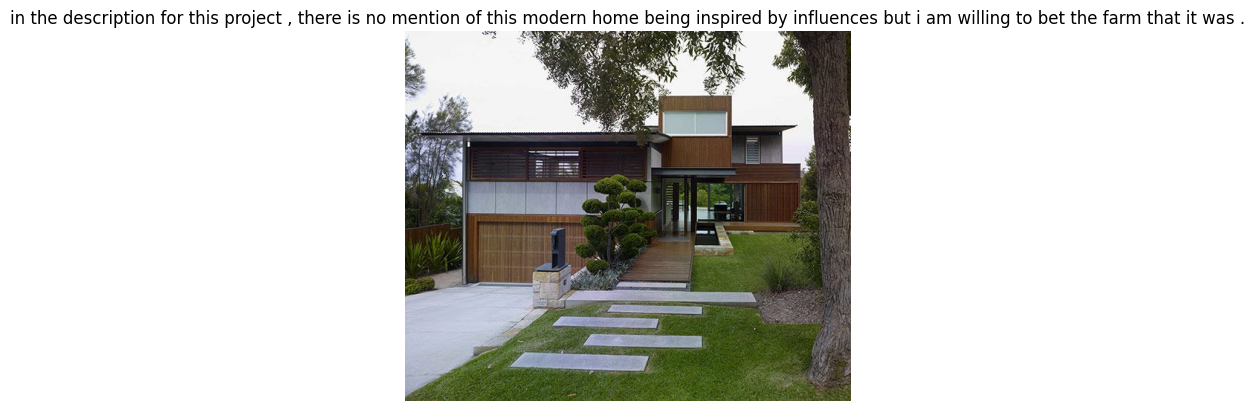

In [63]:
import matplotlib.pyplot as plt

plt.imshow(x['image'].permute(1, 2, 0))
plt.axis('off')
plt.title(x['caption'])
plt.show()

In [69]:
%pwd

'/weka/prior-default/georges/research/U-ViT/scripts'

In [1]:
import sys
sys.path = ['..'] + sys.path

from datasets import CC3MDataset

In [ ]:
dataset = CC3MDataset(
    "/weka/oe-data-default/georges/datasets/cc3m-wds/cc3m-train-{0000..0575}.tar",
    resolution=256,
)

/opt/miniconda3/envs/uvit/lib/python3.10/site-packages/webdataset/compat.py:389: UserWarning: WebDataset(shardshuffle=...) is None; set explicitly to False or a number
  warnings.warn(


In [5]:
image, text = next(iter(dataset))

In [7]:
text

"a river has burst it 's banks and has spread out onto arable farmland alongside"

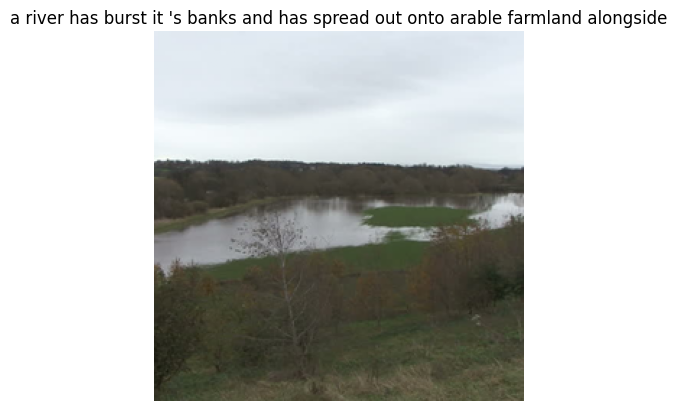

In [6]:
import matplotlib.pyplot as plt

plt.imshow((image.transpose(1, 2, 0) + 1) / 2)  # assuming image is normalized to [-1, 1]
plt.axis('off')
plt.title(text)
plt.show()